In [2]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score, classification_report

import pickle


In [9]:
# LOAD DATA (SAME AS YOUR CODE)
# =========================
data = pd.read_csv('/content/spam - spam.csv', encoding='latin-1')

In [10]:
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [11]:
# Drop unwanted columns
data = data.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)

# Rename columns
data = data.rename(columns={"v1": "Label", "v2": "SMS"})

In [12]:
data.describe()

,Label,SMS
count,5572,5572
unique,2,5163
top,ham,"Sorry, I'll call later"
freq,4825,30


In [13]:
data.isnull().sum()

,0
Label,0
SMS,0


In [14]:
data.value_counts()

Label  SMS                                                                                                                                                                                                          
ham    Sorry, I'll call later                                                                                                                                                                                           30
       I cant pick the phone right now. Pls send a message                                                                                                                                                              12
       Ok...                                                                                                                                                                                                            10
       Your opinion about me? 1. Over 2. Jada 3. Kusruthi 4. Lovable 5. Silent 6. Spl character 7. Not matured 8. Stylish 9. Simple Pls reply..                                                                          4
       Ok                                                                                                                                                                                                                4
                                                                                                                                                                                                                        ..
       I wonder how you got online, my love ? Had you gone to the net cafe ? Did you get your phone recharged ? Were you on a friends net ? I think of you, boytoy                                                       1
       I wish! I don't think its gonna snow that much. But it will be more than those flurries we usually get that melt before they hit the ground. Eek! We haven't had snow since &lt;#&gt; before I was even born!     1
       I wish u were here. I feel so alone                                                                                                                                                                               1
       I wish things were different. I wonder when i will be able to show you how much i value you. Pls continue the brisk walks no drugs without askin me please and find things to laugh about. I love you dearly.     1
       I wont. So wat's wit the guys                                                                                                                                                                                     1
Name: count, Length: 5163, dtype: int64

In [15]:
# SPLIT DATA
# =========================
x = data["SMS"]
y = data["Label"]

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [18]:
# TEXT VECTORIZATION
# =========================
count_vector = CountVectorizer()

x_train_data = count_vector.fit_transform(x_train)
x_test_data = count_vector.transform(x_test)


In [20]:
# MULTIPLE MODELS (comparing models perfomance)
# =========================
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='linear')
}

results = {}

print("\n===== MODEL TRAINING =====\n")

for name, model in models.items():
    model.fit(x_train_data, y_train)
    y_pred = model.predict(x_test_data)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)



===== MODEL TRAINING =====

Naive Bayes Accuracy: 0.9830
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.99      0.89      0.93       150

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

--------------------------------------------------
Logistic Regression Accuracy: 0.9794
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       1.00      0.85      0.92       150

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115

--------------------------------------------------
SVM Accuracy: 0.9803
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       

In [21]:
# BEST MODEL SELECTION
# =========================
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print(f"\n✅ Best Model: {best_model_name}")


✅ Best Model: Naive Bayes


In [22]:
# SAVE MODEL & VECTORIZER(for the stramlit App purpose)
# =========================
pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(count_vector, open("vectorizer.pkl", "wb"))

print("\nModel and vectorizer saved successfully!")


Model and vectorizer saved successfully!


In [23]:
# MANUAL TEST
# =========================
msg = "Congratulations! You won a free ticket!"
msg_vector = count_vector.transform([msg])

prediction = best_model.predict(msg_vector)
print("\nSample Prediction:", prediction)


Sample Prediction: ['spam']


In [25]:
# User Input TEST
# =========================
msg = input("Enter a message: ")
msg_vector = count_vector.transform([msg])

prediction = best_model.predict(msg_vector)
print("\nSample Prediction:", prediction)

Enter a message: Thanks

Sample Prediction: ['ham']


                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes  0.982960   0.985185  0.886667  0.933333
1  Logistic Regression  0.979372   1.000000  0.846667  0.916968
2                  SVM  0.980269   0.977612  0.873333  0.922535


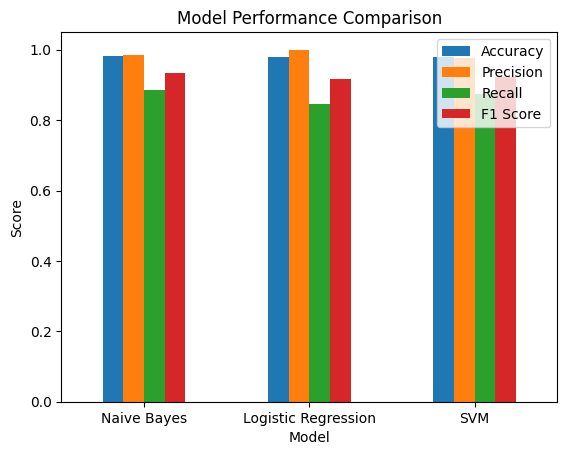

In [43]:
#Model Comparison GRAPH
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_data = []

for name, model in models.items():
    model.fit(x_train_data, y_train)
    y_pred = model.predict(x_test_data)

    comparison_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label='spam'),
        "Recall": recall_score(y_test, y_pred, pos_label='spam'),
        "F1 Score": f1_score(y_test, y_pred, pos_label='spam')
    })

df_compare = pd.DataFrame(comparison_data)
print(df_compare)

#visualization
df_compare.set_index("Model").plot(kind='bar')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

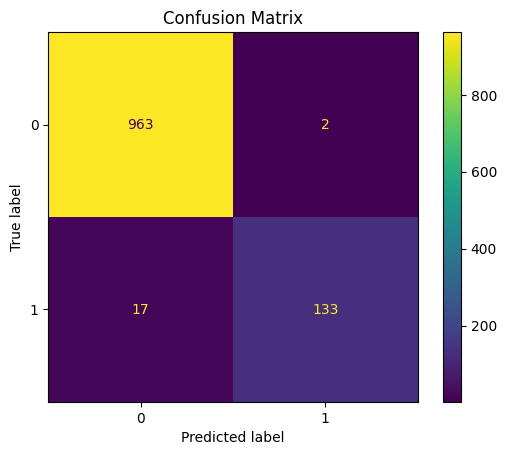

In [31]:
#Confusion Matrix (For Best Model) - Shows false positives / false negatives
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, best_model.predict(x_test_data))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

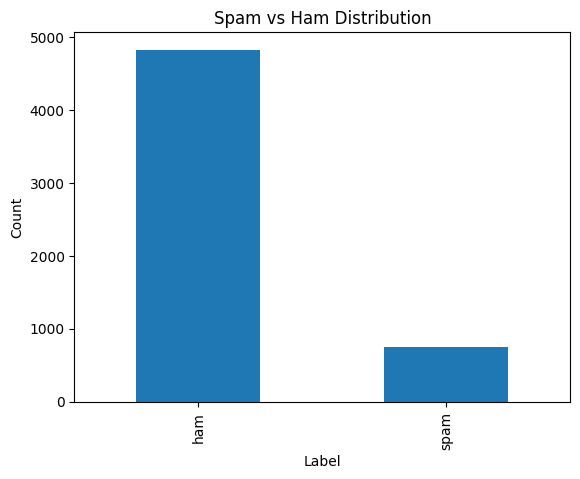

In [32]:
#Spam vs Ham Distribution
data['Label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [44]:
'''Instead of relying only on accuracy, I compared precision, recall, and F1-score to better understand spam detection performance.'''
#I visualized model performance using a bar chart to compare accuracy.
#I also used a confusion matrix to analyze misclassification.
#Additionally, I checked class distribution to understand imbalance.

'Instead of relying only on accuracy, I used cross-validation for robust evaluation and \nalso compared precision, recall, and F1-score to better understand spam detection performance.'